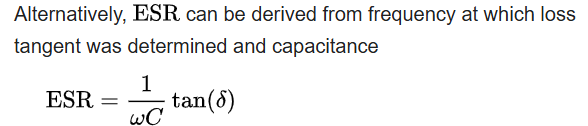

In [20]:
0.01/(2*PI*1000 * 0.47e-6)
val ESR_100Hz = 0.170
val ESR_50Hz = ESR_100Hz * 1.6
println("ESR a 50Hz: ${String.format("%.2f", ESR_50Hz)} Ω")

//Z^2 = R^2 + X^2 => C = sqrt(Z^2 - X^2)
val X_50Hz = sqrt(8f.pow(2) - ESR_50Hz.pow(2))
val C_50Hz = 1 / (2*PI*50*X_50Hz)
println("C a 50Hz: ${String.format("%.2E", C_50Hz)} Ω")

ESR a 50Hz: 0,27 Ω
C a 50Hz: 3,98E-04 Ω


In [6]:
data class Complex(val real: Double, val imaginary: Double) {
    // Overload arithmetic operators for natural syntax
    operator fun plus(other: Complex) = Complex(real + other.real, imaginary + other.imaginary)
    operator fun minus(other: Complex) = Complex(real - other.real, imaginary - other.imaginary)
    operator fun times(other: Complex) = Complex(
        real * other.real - imaginary * other.imaginary,
        real * other.imaginary + imaginary * other.real
    )
    operator fun times(other: Double) = times(Complex(other,0.0))
    operator fun div(other: Complex): Complex {
        val denominator = other.real * other.real + other.imaginary * other.imaginary
        return Complex(
            (real * other.real + imaginary * other.imaginary) / denominator,
            (imaginary * other.real - real * other.imaginary) / denominator
        )
    }

    // Additional operations
    fun conjugate() = Complex(real, -imaginary)
    fun modulus() = kotlin.math.sqrt(real * real + imaginary * imaginary)
}

operator fun Double.div(other: Complex): Complex {
    return Complex(this, 0.0).div(other)
}

In [40]:
val f = 50
val w = 2 * PI * f
val Zload = Complex(real = 500.0, imaginary = 0.0)
val Zc470 = Complex(real = 0.270, imaginary = -1/(w * 398e-6))
val Zc047 = Complex(real = 3.386, imaginary = -1/(w * 0.47e-6))
//val Ztotal = (Zload * (Zc470 * Zc470 * Zc470 * Zc470) * Zc047) / (Zload + (Zc470 * 4.0) + Zc047)
val Ztotal = 1.0 / (1.0/Zload + 4.0/Zc470 + 1.0/Zc047)

//Capacitores de 470uC
//ESR       = 170 mOhm
//Irms_max  = 6.69 A
val IRippleMax470 = 6.69
//Corriente maxima por el convertidor impuesta por el cap de 470uC
val IlRmsMax470 = 2 * Zc470.modulus() / Ztotal.modulus() * IRippleMax470

//Capacitor de 0.47uC
//ESR       = 100 mOhm
//Irms_max  = 6 A
val IRippleMax047 = 0.3 //Actualizar
//Corriente maxima por el convertidor impuesta por el cap de 470uC
val IlRmsMax047 = 2 * Zc047.modulus() / Ztotal.modulus() * IRippleMax047

println(Zload.modulus())
println(Zc470.modulus())
println(Zc047.modulus())
println(Ztotal.modulus())
println("Capacitor 470uF: Corriente maxima=$IlRmsMax470")
println("Capacitor 0.47uF: Corriente maxima=$IlRmsMax047")

500.0
8.002292075815909
6772.551616298994
1.9996967841345243
Capacitor 470uF: Corriente maxima=53.543451599217036
Capacitor 0.47uF: Corriente maxima=2032.0735633618108
